# 01 · Carga y exploración

Primer contacto con los CSV: columnas, tipos, cardinalidad de las categóricas y
forma de la demanda a lo largo del día y de la semana.

In [1]:
import sys, warnings
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=FutureWarning)

DATASETS = RAIZ / "datasets"
print("raiz     :", RAIZ)
print("datasets :", DATASETS, "->", "existe" if DATASETS.exists() else "FALTA")

raiz     : C:\Users\manue\OneDrive\Documentos\PROYECTOS PORTAFOLIO REAL\SIEM EXPLORER
datasets : C:\Users\manue\OneDrive\Documentos\PROYECTOS PORTAFOLIO REAL\SIEM EXPLORER\datasets -> existe


## Demanda real del SIN (XM)

Una fila por hora. Es la serie objetivo del modelo.

In [2]:
from ingesta.normalizar import xm_cliente_a_esquema_comun

crudo_xm = pd.read_csv(DATASETS / "xm" / "xm_demareal_sistema.csv", parse_dates=["timestamp"])
xm = xm_cliente_a_esquema_comun(crudo_xm)
print(f"{len(xm):,} filas · {xm.fecha_hora.min()} .. {xm.fecha_hora.max()}")
xm.head()

49,824 filas · 2021-01-01 00:00:00-05:00 .. 2026-09-07 23:00:00-05:00


,fecha_hora,fuente,metrica,entidad,valor_kwh,version
0,2021-01-01 00:00:00-05:00,xm,DemaReal,Sistema,6555224.81,None
1,2021-01-01 01:00:00-05:00,xm,DemaReal,Sistema,6366973.29,None
2,2021-01-01 02:00:00-05:00,xm,DemaReal,Sistema,6137217.99,None
3,2021-01-01 03:00:00-05:00,xm,DemaReal,Sistema,5957885.01,None
4,2021-01-01 04:00:00-05:00,xm,DemaReal,Sistema,5837571.45,None


In [3]:
print(xm.dtypes.to_string())
print()
print("filas por marca de tiempo:", round(len(xm) / xm.fecha_hora.nunique(), 2))
print("nulos:", int(xm.valor_kwh.isna().sum()))

fecha_hora    datetime64[ns, America/Bogota]
fuente                                object
metrica                               object
entidad                               object
valor_kwh                            float64
version                               object

filas por marca de tiempo: 1.0
nulos: 0


### Perfil horario y semanal

La demanda tiene dos estacionalidades muy marcadas. Verlas ahora ahorra
sorpresas: un criterio de atípicos que ignore la hora del día marcará como raros
los picos normales de la tarde.

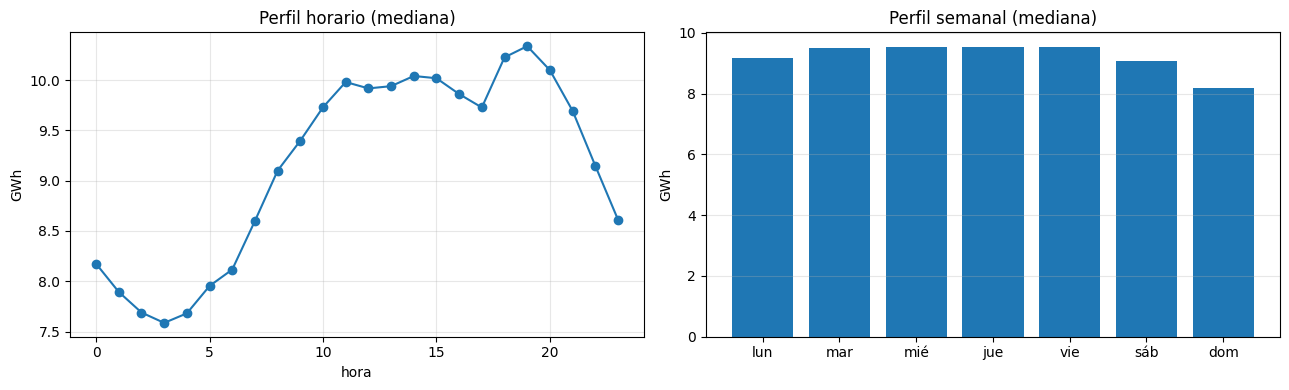

In [4]:
hora = xm.fecha_hora.dt.hour
dia = xm.fecha_hora.dt.dayofweek

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
perfil = xm.groupby(hora).valor_kwh.median() / 1e6
ejes[0].plot(perfil.index, perfil.values, marker="o")
ejes[0].set(title="Perfil horario (mediana)", xlabel="hora", ylabel="GWh")
ejes[0].grid(alpha=.3)

semanal = xm.groupby(dia).valor_kwh.median() / 1e6
ejes[1].bar(["lun", "mar", "mié", "jue", "vie", "sáb", "dom"], semanal.values)
ejes[1].set(title="Perfil semanal (mediana)", ylabel="GWh")
ejes[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

## Catálogo de métricas de XM

Las 193 métricas disponibles. `MaxDays` es el límite de días por llamado.

In [5]:
cat = pd.read_csv(DATASETS / "xm" / "xm_catalogo_metricas.csv")
print(f"{len(cat)} métricas · MaxDays presentes: {sorted(cat.MaxDays.unique())}")
print(cat.Type.value_counts().to_string())
cat[cat.MetricName.str.contains("Demanda", case=False, na=False)][
    ["MetricId", "Entity", "Type", "MaxDays", "MetricUnits"]
].head(15)

193 métricas · MaxDays presentes: [31, 731]
Type
HourlyEntities     115
DailyEntities       57
MonthlyEntities     14
ListsEntities        7


,MetricId,Entity,Type,MaxDays,MetricUnits
0,DemaReal,Sistema,HourlyEntities,31,kWh
1,DemaReal,Agente,HourlyEntities,31,kWh
3,DemaCome,Sistema,HourlyEntities,31,kWh
12,DemaCome,Agente,HourlyEntities,31,kWh
33,DemaOR,Agente,HourlyEntities,31,kWh
51,DemaComeReg,Agente,HourlyEntities,31,kWh
52,DemaComeNoReg,Agente,HourlyEntities,31,kWh
53,DemaComeReg,Sistema,HourlyEntities,31,kWh
54,DemaComeNoReg,Sistema,HourlyEntities,31,kWh
56,DemaComeNoReg,CIIU,HourlyEntities,31,kWh


## SIMEM desagregado

⚠️ **La trampa del proyecto.** Sobre una misma `FechaHora` conviven varias
versiones de liquidación. Sumar sin filtrarlas multiplica la demanda por el
número de versiones, y el resultado sigue pareciendo una curva plausible.

Los CSV anuales pesan decenas o cientos de MB, así que aquí se lee una muestra.

In [6]:
anuales = sorted(p for p in DATASETS.glob("simem/simem_14fabb_*.csv") if "nacional" not in p.name)
simem = None
if anuales:
    ultimo = anuales[-1]
    simem = pd.read_csv(ultimo, parse_dates=["timestamp"], nrows=300_000)
    print(f"{ultimo.name}: {len(simem):,} filas leídas (muestra)")
    print("columnas:", list(simem.columns))
    print("versiones presentes:", sorted(simem.Version.unique()))
    print("filas por marca de tiempo:", round(len(simem) / simem.timestamp.nunique(), 1))
else:
    print("Aún no hay CSV anuales de SIMEM.")

simem_14fabb_2026.csv: 300,000 filas leídas (muestra)
columnas: ['timestamp', 'fuente', 'identificador', 'CodigoVariable', 'FechaHora', 'CodigoSICAgente', 'TipoMercado', 'Version', 'Valor', 'UnidadMedida', 'CodigoDuracion']
versiones presentes: ['TX2', 'TX3', 'TX4', 'TXF', 'TXR']
filas por marca de tiempo: 459.4


In [7]:
from ingesta.normalizar import simem_agregar_nacional

if simem is not None:
    ingenuo = simem.groupby("timestamp").Valor.sum()
    correcto = simem_agregar_nacional(simem).set_index("fecha_hora").valor_kwh
    factor = (ingenuo.values / correcto.values)
    print("versiones por hora     :", sorted(simem.groupby("timestamp").Version.nunique().unique()))
    print(f"suma ingenua (mediana) : {ingenuo.median()/1e6:,.2f} GWh")
    print(f"suma correcta (mediana): {correcto.median()/1e6:,.2f} GWh")
    print(f"factor de inflación    : {factor.min():.1f}x .. {factor.max():.1f}x")

versiones por hora     :

 [5]
suma ingenua (mediana) : 46.31 GWh
suma correcta (mediana): 9.26 GWh
factor de inflación    : 5.0x .. 5.0x


## Demanda comercial por CIIU

La métrica con dimensiones extra: `Activity` y `Subactivity` vienen dentro de
`Values`, no en el `Id` de la entidad, así que por cada hora hay cientos de
filas legítimas, una por subactividad.

xm_demacomenoreg_ciiu_2026.csv.gz: 400,000 filas leídas (muestra)
actividades   : 21
subactividades: 353
duplicados sobre la clave completa: 0


C:\Users\manue\AppData\Local\Temp\ipykernel_18912\527923435.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


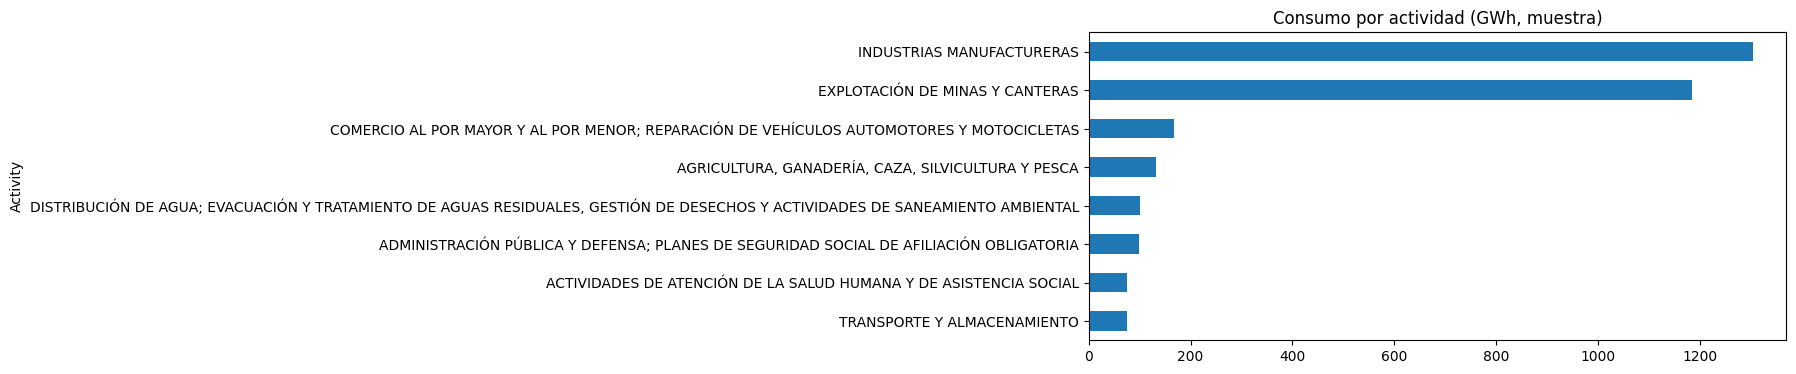

In [8]:
ciiu_archivos = sorted(p for p in DATASETS.glob("xm/ciiu/*.csv*") if p.suffix != ".tmp")
if ciiu_archivos:
    ciiu = pd.read_csv(ciiu_archivos[-1], parse_dates=["timestamp"], nrows=400_000)
    print(f"{ciiu_archivos[-1].name}: {len(ciiu):,} filas leídas (muestra)")
    print("actividades   :", ciiu.Activity.nunique())
    print("subactividades:", ciiu.Subactivity.nunique())
    clave = ["timestamp", "Activity", "Subactivity"]
    print("duplicados sobre la clave completa:", int(ciiu.duplicated(subset=clave).sum()))
    top = ciiu.groupby("Activity").valor.sum().sort_values().tail(8) / 1e6
    top.plot.barh(figsize=(9, 4), title="Consumo por actividad (GWh, muestra)")
    plt.tight_layout(); plt.show()
else:
    print("Aún no hay CSV de CIIU. Ejecuta el script sin --sin-ciiu.")